# 04. Distributions, Variability, and Tail Risk

Averages are useful, but they are often too forgiving. Two support systems can have similar mean response times while one produces frequent unpleasant delays and the other remains stable. A decision-maker who only sees the average may conclude that the systems are interchangeable. A decision-maker who sees the whole distribution will usually disagree.

We study distributions as decision objects. We will use a synthetic seller-support operation to examine center, spread, skew, quantiles, exceedance probabilities, and the operational meaning of tail risk. The goal is not to memorize distribution names in the abstract. The goal is to understand why the shape of uncertainty matters whenever a business promise depends on reliability across the whole distribution.


## Learning Objectives

By the end of this lecture, you should be able to:

1. Explain why a distribution contains more decision-relevant information than a single point estimate.
2. Distinguish center, spread, skew, and tail behavior in operational data.
3. Match common business phenomena to useful distributional families or approximations.
4. Use quantiles and exceedance probabilities to summarize service-risk exposure.
5. Recognize when heavy tails or mixture behavior make the mean alone misleading.
6. Compare systems that have similar averages but materially different tail risk.
7. Translate distributional evidence into a professional recommendation about operational readiness.


## Mathematical Core: Distributions, Quantiles, and Tail Risk

A distribution describes more than the average. If $Y$ is an operational outcome such as response time, backlog, cost, or loss, its distribution is summarized by probabilities over events:

$$
F_Y(y) = P(Y \le y), \qquad P(Y > y) = 1 - F_Y(y).
$$

The mean and variance answer useful but limited questions:

$$
\mu = \mathbb{E}[Y], \qquad \sigma^2 = \operatorname{Var}(Y) = \mathbb{E}\left[(Y - \mu)^2\right].
$$

Decision makers often care about quantiles and tail probabilities instead:

$$
q_p = \inf\left\{y: F_Y(y) \ge p\right\}, \qquad P(Y > c),
$$

where $q_p$ is the $p$th quantile and $c$ is a service, cost, or risk threshold. A system can have an acceptable mean and still fail in the tail if $P(Y > c)$ is large.

For severe risk, a tail-conditional summary is often more informative than a single percentile:

$$
\mathbb{E}\left[Y \mid Y > q_{0.95}\right].
$$

This is the average outcome among the worst five percent of cases. In decision settings, it helps distinguish occasional mild misses from rare but damaging operational failures.

In [1]:
# Load the libraries and notebook settings used in the examples below.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 24)

from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio root so shared notebook helpers import reliably.
    
    Parameters:
        start: Starting path for the upward project-root search.
    
    Returns:
        A `Path` pointing to the nearest portfolio root that contains `notebooks/_shared`; if no such parent is found, the original starting path is returned.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.display import smart_display

## 1. Why the Full Distribution Matters

If leadership asks whether a premium service promise is safe, a mean response time is only a partial answer. The promise can fail because of the tail even when the center looks acceptable. A service system that resolves most tickets quickly but occasionally breaks down can still damage trust, trigger credits, and overload escalation teams.

This is why distributional thinking matters. A distribution tells us what is typical, how much variation surrounds the typical case, how asymmetric the process is, and how often rare painful outcomes occur.


| Distributional Idea | Operational Interpretation |
|---|---|
| Center | What usually happens on average or at the median |
| Spread | How much performance varies from ticket to ticket or day to day |
| Skew | Whether the distribution has a long high side or low side |
| Tail risk | How often unusually bad outcomes occur |
| Quantile | A service threshold such as the 90th or 95th percentile |
| Mixture behavior | Evidence that routine cases and escalation cases come from different regimes |


This language gives us a more mature way to talk about performance. The mean is one summary of the center, but not the distribution. The standard deviation is one summary of spread, but not the tail. A quantile can be more relevant than a mean when a business promise is defined by worst-case experience.

In decision science, we do not look at distributions because they are mathematically elegant. We look at them because operations fail in the tails.

## 2. A Support Operation With Both Routine and Escalation Behavior

We will simulate one year of marketplace support activity. Ticket arrivals vary by day, severity shapes difficulty, queue congestion changes service speed, and a small fraction of cases escalate into much longer delays. That escalation mechanism is important because it creates a long right tail even when most tickets are handled reasonably quickly.

This is a good statistical teaching environment because real service systems are rarely generated by a single clean textbook distribution. They are often mixtures of routine work and exceptional work.


In [2]:
# Define helper functions and reusable utilities for this section.
rng = np.random.default_rng(2034)

def sigmoid(x):
    """
    Transform a linear score into a probability with the logistic function.
    
    Parameters:
        x: Input value or array passed to the mathematical transform.
    
    Returns:
        A scalar or NumPy array containing the logistic transform of `x`, useful for converting linear scores into probabilities.
    
    Idea:
        Convert additive risk drivers into bounded probabilities, allowing synthetic event rates to respond smoothly to covariates.
    """
    return 1.0 / (1.0 + np.exp(-x))


day_levels = np.array(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
severity_levels = ["low", "medium", "high", "urgent"]
channel_levels = np.array(["chat", "email", "phone"])
seller_tier_levels = np.array(["standard", "growth", "enterprise"])

n_days = 365
day_id = np.arange(1, n_days + 1)
day_of_week = day_levels[(day_id - 1) % 7]

base_daily_load = np.select(
    [
        day_of_week == "Mon",
        day_of_week == "Tue",
        day_of_week == "Wed",
        day_of_week == "Thu",
        day_of_week == "Fri",
        day_of_week == "Sat",
        day_of_week == "Sun",
    ],
    [240, 220, 215, 215, 230, 165, 155],
)
latent_day_pressure = rng.lognormal(mean=0.0, sigma=0.14, size=n_days)
tickets_today = np.maximum(80, rng.poisson(base_daily_load * latent_day_pressure)).astype(int)

days = pd.DataFrame(
    {
        "day_id": day_id,
        "day_of_week": day_of_week,
        "tickets_today": tickets_today,
    }
)
days["daily_congestion_index"] = (
    (days["tickets_today"] - days["tickets_today"].mean()) / days["tickets_today"].std()
)

tickets = days.loc[days.index.repeat(days["tickets_today"])].copy().reset_index(drop=True)
n_tickets = len(tickets)

tickets["seller_tier"] = rng.choice(seller_tier_levels, size=n_tickets, p=[0.61, 0.25, 0.14])
tickets["priority_contract"] = (
    (tickets["seller_tier"] == "enterprise")
    | ((tickets["seller_tier"] == "growth") & (rng.random(n_tickets) < 0.36))
).astype(int)

latent_complexity = rng.normal(
    loc=-0.14
    + 0.20 * (tickets["seller_tier"] == "growth").astype(float)
    + 0.42 * (tickets["seller_tier"] == "enterprise").astype(float)
    + 0.20 * tickets["daily_congestion_index"].to_numpy(),
    scale=0.80,
    size=n_tickets,
)
severity_score = latent_complexity + 0.20 * tickets["priority_contract"].to_numpy() + rng.normal(0, 0.90, size=n_tickets)
tickets["severity"] = pd.cut(
    severity_score,
    bins=[-np.inf, -0.55, 0.35, 1.05, np.inf],
    labels=severity_levels,
)
tickets["severity"] = pd.Categorical(tickets["severity"], categories=severity_levels, ordered=True)

channel_probability_map = {
    "low": [0.64, 0.27, 0.09],
    "medium": [0.46, 0.35, 0.19],
    "high": [0.26, 0.38, 0.36],
    "urgent": [0.09, 0.30, 0.61],
}

channel = np.empty(n_tickets, dtype=object)
for sev, probs in channel_probability_map.items():
    mask = tickets["severity"] == sev
    channel[mask] = rng.choice(channel_levels, size=mask.sum(), p=probs)
tickets["channel"] = channel

overnight_prob = sigmoid(
    -2.10
    + 0.65 * (tickets["severity"] == "urgent").astype(float).to_numpy()
    + 0.26 * (tickets["channel"] == "phone").astype(float).to_numpy()
    + 0.20 * tickets["daily_congestion_index"].to_numpy()
    + 0.16 * tickets["day_of_week"].isin(["Sat", "Sun"]).astype(float).to_numpy()
)
tickets["overnight"] = rng.binomial(1, overnight_prob)

analyst_experience = rng.normal(
    loc=0.28
    - 0.22 * tickets["daily_congestion_index"].to_numpy()
    - 0.08 * (tickets["severity"] == "urgent").astype(float).to_numpy(),
    scale=0.80,
    size=n_tickets,
)
tickets["analyst_experience"] = np.clip(analyst_experience, -2.5, 2.5)

base_log_response = (
    1.88
    + tickets["severity"].map({"low": -0.25, "medium": 0.00, "high": 0.42, "urgent": 0.80}).to_numpy()
    + 0.24 * tickets["daily_congestion_index"].to_numpy()
    + 0.20 * tickets["overnight"].to_numpy()
    + 0.10 * (tickets["channel"] == "phone").astype(float).to_numpy()
    - 0.10 * tickets["analyst_experience"].to_numpy()
    + rng.normal(0, 0.32, size=n_tickets)
)
routine_response = np.exp(base_log_response)

escalation_prob = sigmoid(
    -2.95
    + 0.52 * (tickets["severity"] == "high").astype(float).to_numpy()
    + 1.05 * (tickets["severity"] == "urgent").astype(float).to_numpy()
    + 0.42 * tickets["daily_congestion_index"].to_numpy()
    + 0.20 * (tickets["channel"] == "phone").astype(float).to_numpy()
)
tickets["escalated_case"] = rng.binomial(1, escalation_prob)
escalation_delay = tickets["escalated_case"].to_numpy() * rng.lognormal(mean=np.log(24), sigma=0.70, size=n_tickets)

tickets["first_response_minutes"] = routine_response + escalation_delay
tickets["response_breach"] = (tickets["first_response_minutes"] > 15).astype(int)
tickets["severe_delay"] = (tickets["first_response_minutes"] > 30).astype(int)
tickets["service_credit"] = np.where(
    tickets["response_breach"] == 1,
    np.where(tickets["priority_contract"] == 1, 90.0, 25.0),
    0.0,
)

daily_metrics = (
    tickets.groupby(["day_id", "day_of_week"], observed=True)
    .agg(
        tickets_today=("first_response_minutes", "size"),
        mean_response_minutes=("first_response_minutes", "mean"),
        median_response_minutes=("first_response_minutes", "median"),
        p95_response_minutes=("first_response_minutes", lambda x: x.quantile(0.95)),
        breach_rate=("response_breach", "mean"),
        severe_delay_rate=("severe_delay", "mean"),
        daily_service_credit=("service_credit", "sum"),
    )
    .reset_index()
)

simulation_overview = pd.DataFrame(
    [
        {"quantity": "Days simulated", "value": len(days)},
        {"quantity": "Tickets simulated", "value": len(tickets)},
        {"quantity": "Mean tickets per day", "value": daily_metrics["tickets_today"].mean()},
        {"quantity": "Ticket-level response breach rate", "value": tickets["response_breach"].mean()},
        {"quantity": "Ticket-level severe delay rate", "value": tickets["severe_delay"].mean()},
        {"quantity": "Mean daily service credit", "value": daily_metrics["daily_service_credit"].mean()},
    ]
)

smart_display(simulation_overview)

,quantity,value
0,Days simulated,365.000
1,Tickets simulated,75886.000
2,Mean tickets per day,207.907
3,Ticket-level response breach rate,0.253
4,Ticket-level severe delay rate,0.084
5,Mean daily service credit,2292.575


### Dataset and Experiment Design

The synthetic dataset represents daily support operations with both routine work and escalation behavior. The key outcome is ticket workload or resolution burden, but the important feature is not only its average. The process deliberately creates skewness, rare high-load days, and tail events that matter for staffing and service commitments.

We use that dataset to compare distributional summaries. We look at common distribution shapes, center, spread, quantiles, exceedance probabilities, and daily risk. The experiment is designed to make one point impossible to miss: two processes can have similar averages while creating very different operational risk.

Because the distribution is simulated, we know why the tails exist. That lets the notebook connect formulas about quantiles and exceedance probabilities to an applied question: how often will the system enter a region where ordinary averages no longer protect the decision maker?

## 3. Common Distribution Families in Operational Data

Real business data are rarely exact textbook draws, but distribution families still provide useful approximations and intuition.


| Phenomenon | Useful Distributional Lens | Why It Can Fit |
|---|---|---|
| Whether one ticket breaches the SLA | Bernoulli | The outcome is binary: breach or no breach |
| Number of breaches in a fixed batch of tickets | Binomial | It counts how many binary failures occur in a fixed number of opportunities |
| Ticket arrivals in short windows | Poisson-like | Counts per interval often behave approximately like random arrivals, though real systems can be more variable |
| Response time or resolution time | Lognormal or gamma-like | These are positive, skewed, and often have long right tails |
| Daily service credits | Compound or mixture distribution | Many days are moderate, but rare bad days create extra mass in the tail |
| Escalated vs routine tickets together | Mixture distribution | One process governs ordinary cases and another governs escalation cases |


In [3]:
# Build a summary table that supports the interpretation in the surrounding notes.
family_check_table = pd.DataFrame(
    [
        {
            "phenomenon": "Response breach indicator",
            "empirical_mean": tickets["response_breach"].mean(),
            "empirical_variance": tickets["response_breach"].var(),
            "theoretical_check": tickets["response_breach"].mean() * (1 - tickets["response_breach"].mean()),
            "distribution_hint": "Bernoulli-like",
        },
        {
            "phenomenon": "Daily ticket count",
            "empirical_mean": daily_metrics["tickets_today"].mean(),
            "empirical_variance": daily_metrics["tickets_today"].var(),
            "theoretical_check": daily_metrics["tickets_today"].var() / daily_metrics["tickets_today"].mean(),
            "distribution_hint": "Poisson baseline with overdispersion if variance/mean > 1",
        },
        {
            "phenomenon": "First-response minutes",
            "empirical_mean": tickets["first_response_minutes"].mean(),
            "empirical_variance": tickets["first_response_minutes"].var(),
            "theoretical_check": tickets["first_response_minutes"].median(),
            "distribution_hint": "Positive skew suggests lognormal/gamma or mixture behavior",
        },
        {
            "phenomenon": "Daily service credit",
            "empirical_mean": daily_metrics["daily_service_credit"].mean(),
            "empirical_variance": daily_metrics["daily_service_credit"].var(),
            "theoretical_check": daily_metrics["daily_service_credit"].quantile(0.95),
            "distribution_hint": "Tail-sensitive aggregate with compound behavior",
        },
    ]
)

smart_display(family_check_table)


,phenomenon,empirical_mean,empirical_variance,theoretical_check,distribution_hint
0,Response breach indicator,0.253,0.189,0.189,Bernoulli-like
1,Daily ticket count,207.907,1973.041,9.490,Poisson baseline with overdispersion if varian...
2,First-response minutes,13.223,206.444,8.599,Positive skew suggests lognormal/gamma or mixt...
3,Daily service credit,2292.575,3321072.608,6058.000,Tail-sensitive aggregate with compound behavior


The family-check table is deliberately heuristic. We are not proving that these variables come from exact parametric families. We are using distribution families as lenses.

For example, the response-breach indicator behaves like a Bernoulli variable because its empirical variance is close to the familiar $p(1-p)$ form. Daily ticket counts have a count-distribution flavor, but the variance-to-mean ratio may exceed 1 because real days differ in underlying intensity. Response times are positive and skewed, which immediately points us away from a symmetric normal interpretation. Daily credit totals look like a compound outcome because they aggregate many ticket-level realizations, including rare bad cases.

## 4. Center, Spread, and Skew

We now move from distribution families to concrete summaries. For operational variables, a good first pass often includes the mean, median, standard deviation, interquartile range, high quantiles, and the maximum. The combination is more informative than any one statistic alone.


In [4]:
# Define helper functions so repeated calculations stay readable.
def summarize_distribution(values, label):
    """
    Summarize distribution into a compact table or record.
    
    Parameters:
        values: Numeric values used by the statistic or interval helper.
        label: Human-readable label attached to the returned summary.
    
    Returns:
        A dictionary of distribution summaries, including center, spread, quantiles, maximum, and tail-risk metrics.
    
    Idea:
        Summarize center, spread, and tails together so distribution shape is treated as decision evidence.
    """
    s = pd.Series(values)
    return {
        "variable": label,
        "mean": s.mean(),
        "median": s.median(),
        "std_dev": s.std(),
        "iqr": s.quantile(0.75) - s.quantile(0.25),
        "p90": s.quantile(0.90),
        "p95": s.quantile(0.95),
        "p99": s.quantile(0.99),
        "maximum": s.max(),
    }


distribution_summary = pd.DataFrame(
    [
        summarize_distribution(tickets["first_response_minutes"], "Ticket response minutes"),
        summarize_distribution(daily_metrics["tickets_today"], "Daily ticket count"),
        summarize_distribution(daily_metrics["daily_service_credit"], "Daily service credit"),
    ]
)
distribution_summary["mean_minus_median"] = distribution_summary["mean"] - distribution_summary["median"]
smart_display(distribution_summary)

,variable,mean,median,std_dev,iqr,p90,p95,p99,maximum,mean_minus_median
0,Ticket response minutes,13.223,8.599,14.368,9.653,27.070,39.304,73.562,357.297,4.623
1,Daily ticket count,207.907,207.000,44.419,66.000,264.000,280.800,309.680,333.000,0.907
2,Daily service credit,2292.575,1730.000,1822.381,2440.000,4780.000,6058.000,7762.800,9115.000,562.575


The useful information is what the average hides. Variability, skew, and tail exposure can make two options with similar means very different from a staffing, service, or budget perspective.


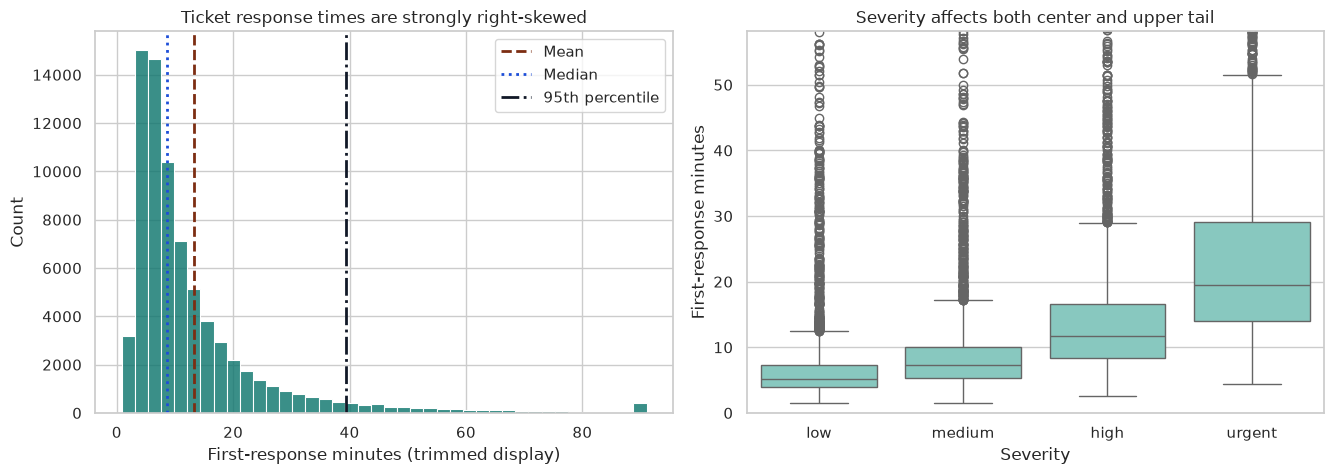

In [5]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.9))

response_trim = tickets["first_response_minutes"].clip(upper=tickets["first_response_minutes"].quantile(0.995))
sns.histplot(response_trim, bins=40, color="#0f766e", alpha=0.82, ax=axes[0])
axes[0].axvline(tickets["first_response_minutes"].mean(), color="#7c2d12", linestyle="--", linewidth=2, label="Mean")
axes[0].axvline(tickets["first_response_minutes"].median(), color="#1d4ed8", linestyle=":", linewidth=2, label="Median")
axes[0].axvline(tickets["first_response_minutes"].quantile(0.95), color="#111827", linestyle="-.", linewidth=2, label="95th percentile")
axes[0].set_title("Ticket response times are strongly right-skewed")
axes[0].set_xlabel("First-response minutes (trimmed display)")
axes[0].legend()

severity_box_data = tickets.sample(n=min(12000, len(tickets)), random_state=2080)
sns.boxplot(data=severity_box_data, x="severity", y="first_response_minutes", color="#7dd3c7", ax=axes[1])
axes[1].set_ylim(0, tickets["first_response_minutes"].quantile(0.98))
axes[1].set_title("Severity affects both center and upper tail")
axes[1].set_xlabel("Severity")
axes[1].set_ylabel("First-response minutes")

plt.tight_layout()
plt.show()


The summary table and plots work best together. For response minutes, the mean sits above the median, which is a classic symptom of right skew. The upper quantiles and maximum are far above the center, confirming that rare slow cases stretch the distribution.

The boxplots show that severity affects the average and the whole shape. Harder tickets are slower on average, more variable, and more exposed to the upper tail.

This is why operational decisions based only on the mean can be misleading. A manager facing seller complaints is often experiencing the upper tail, not the average ticket.

## 5. Quantiles and Exceedance Probabilities

A quantile answers a threshold-style question. The 95th percentile is the value below which 95% of outcomes fall. Formally, the $p$-quantile can be written as

$$
q_p = \inf \{x : F(x) \geq p\}
$$

where $F(x)$ is the cumulative distribution function.

An exceedance probability asks the complementary question:

$$
P(X > c)
$$

In service operations, this is often the most direct risk metric of all. It tells us how often a ticket or a day crosses a practically important boundary.


In [6]:
# Build a summary table that supports the interpretation in the surrounding notes.
tail_table = pd.DataFrame(
    [
        {"quantity": "P(response > 15 minutes)", "value": (tickets["first_response_minutes"] > 15).mean()},
        {"quantity": "P(response > 30 minutes)", "value": (tickets["first_response_minutes"] > 30).mean()},
        {"quantity": "P(response > 60 minutes)", "value": (tickets["first_response_minutes"] > 60).mean()},
        {"quantity": "P(daily credit > 4,500)", "value": (daily_metrics["daily_service_credit"] > 4500).mean()},
        {"quantity": "P(daily credit > 6,000)", "value": (daily_metrics["daily_service_credit"] > 6000).mean()},
        {"quantity": "P(daily credit > 7,500)", "value": (daily_metrics["daily_service_credit"] > 7500).mean()},
    ]
)

smart_display(tail_table)


,quantity,value
0,P(response > 15 minutes),0.253
1,P(response > 30 minutes),0.084
2,P(response > 60 minutes),0.018
3,"P(daily credit > 4,500)",0.123
4,"P(daily credit > 6,000)",0.052
5,"P(daily credit > 7,500)",0.014


The useful information is what the average hides. Variability, skew, and tail exposure can make two options with similar means very different from a staffing, service, or budget perspective.


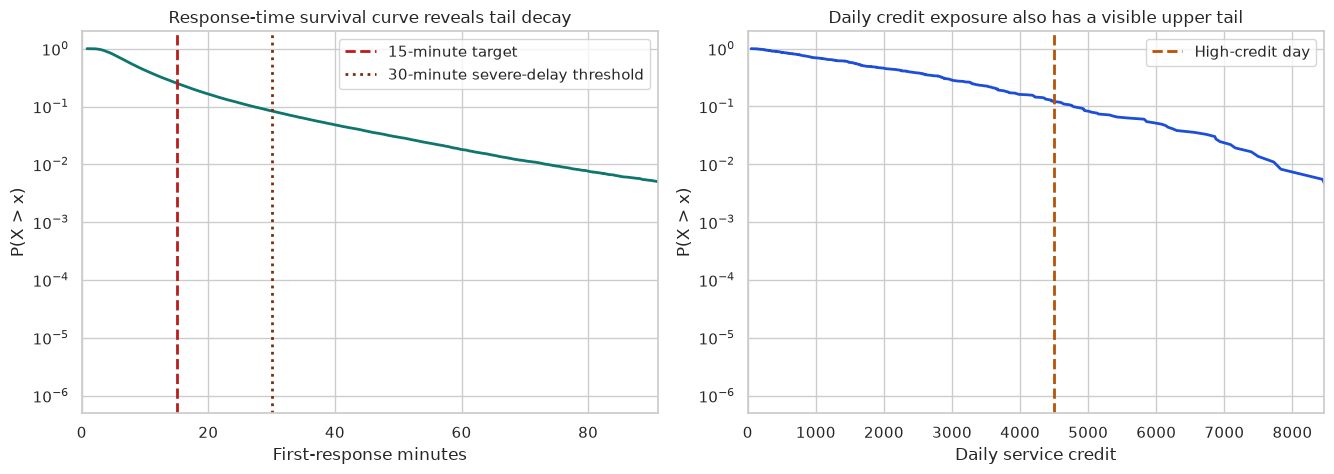

In [7]:
# Define helper functions so repeated calculations stay readable.
def survival_xy(values):
    """
    Convert a sample into empirical survival-curve coordinates.
    
    Parameters:
        values: Numeric values used by the statistic or interval helper.
    
    Returns:
        A tuple of x and y arrays representing the empirical survival curve for the supplied values.
    
    Idea:
        Convert a sample into survival-curve coordinates so tail behavior can be compared without hiding extreme outcomes.
    """
    x = np.sort(np.asarray(values))
    y = 1 - (np.arange(1, len(x) + 1) / len(x))
    y = np.clip(y, 1e-6, None)
    return x, y


x_response, y_response = survival_xy(tickets["first_response_minutes"])
x_credit, y_credit = survival_xy(daily_metrics["daily_service_credit"])

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.9))

axes[0].semilogy(x_response, y_response, color="#0f766e", linewidth=2)
axes[0].axvline(15, color="#b91c1c", linestyle="--", linewidth=2, label="15-minute target")
axes[0].axvline(30, color="#7c2d12", linestyle=":", linewidth=2, label="30-minute severe-delay threshold")
axes[0].set_xlim(0, tickets["first_response_minutes"].quantile(0.995))
axes[0].set_title("Response-time survival curve reveals tail decay")
axes[0].set_xlabel("First-response minutes")
axes[0].set_ylabel("P(X > x)")
axes[0].legend()

axes[1].semilogy(x_credit, y_credit, color="#1d4ed8", linewidth=2)
axes[1].axvline(4500, color="#b45309", linestyle="--", linewidth=2, label="High-credit day")
axes[1].set_xlim(0, daily_metrics["daily_service_credit"].quantile(0.995))
axes[1].set_title("Daily credit exposure also has a visible upper tail")
axes[1].set_xlabel("Daily service credit")
axes[1].set_ylabel("P(X > x)")
axes[1].legend()

plt.tight_layout()
plt.show()

The tail table converts the distribution into concrete risk statements. The survival curves show the same idea more continuously. The log scale is useful because rare events that are nearly invisible on a standard plot become easier to see.

This is the statistical form of a practical question: how often are we outside the comfort zone? If a premium service promise becomes expensive or reputation-damaging when response exceeds 30 minutes, then $P(X > 30)$ is often more operationally relevant than the mean.

## 6. Same Average, Different Risk

A particularly important lesson is that two systems can have nearly the same mean while exposing the business to very different tail risk.

To make that point vivid, consider two alternative routing strategies for priority tickets:

- **Stabilized routing**: a more even workflow with moderate but predictable response times;
- **Aggressive triage**: very fast for most tickets, but occasional serious delays when escalations fail to resolve quickly.

We will simulate the two strategies so that their means are intentionally similar. If the rest of the distribution still differs, then average performance alone is not enough for ranking them.


In [8]:
# Define helper functions and reusable utilities for this section.
n_compare = 70_000

stable_policy = rng.lognormal(
    mean=np.log(14.2) - 0.5 * (0.33 ** 2),
    sigma=0.33,
    size=n_compare,
)

fast_core = rng.lognormal(
    mean=np.log(9.2) - 0.5 * (0.24 ** 2),
    sigma=0.24,
    size=n_compare,
)
slow_tail = rng.lognormal(
    mean=np.log(55.0) - 0.5 * (0.48 ** 2),
    sigma=0.48,
    size=n_compare,
)
unstable_policy = np.where(rng.random(n_compare) < 0.11, slow_tail, fast_core)
unstable_policy = unstable_policy * (stable_policy.mean() / unstable_policy.mean())

def policy_summary(values, label):
    """
    Compute the policy summary quantity used in the statistical or decision-science workflow.
    
    Parameters:
        values: Numeric values used by the statistic or interval helper.
        label: Human-readable label attached to the returned summary.
    
    Returns:
        A dictionary summarizing one policy or service design, including response-time distribution, breach rates, and delay-risk measures.
    
    Idea:
        Summarize simulated policy outcomes in terms that match operational risk: average performance, tail exposure, and service failures.
    """
    s = pd.Series(values)
    return {
        "policy": label,
        "mean": s.mean(),
        "median": s.median(),
        "p90": s.quantile(0.90),
        "p95": s.quantile(0.95),
        "p99": s.quantile(0.99),
        "breach_rate_15min": (s > 15).mean(),
        "severe_delay_rate_30min": (s > 30).mean(),
    }


policy_compare = pd.DataFrame(
    [
        policy_summary(stable_policy, "Stabilized routing"),
        policy_summary(unstable_policy, "Aggressive triage"),
    ]
)

smart_display(policy_compare)

,policy,mean,median,p90,p95,p99,breach_rate_15min,severe_delay_rate_30min
0,Stabilized routing,14.198,13.450,20.560,23.141,29.025,0.370,0.008
1,Aggressive triage,14.198,9.220,25.626,51.868,92.881,0.123,0.093


The useful information is what the average hides. Variability, skew, and tail exposure can make two options with similar means very different from a staffing, service, or budget perspective.


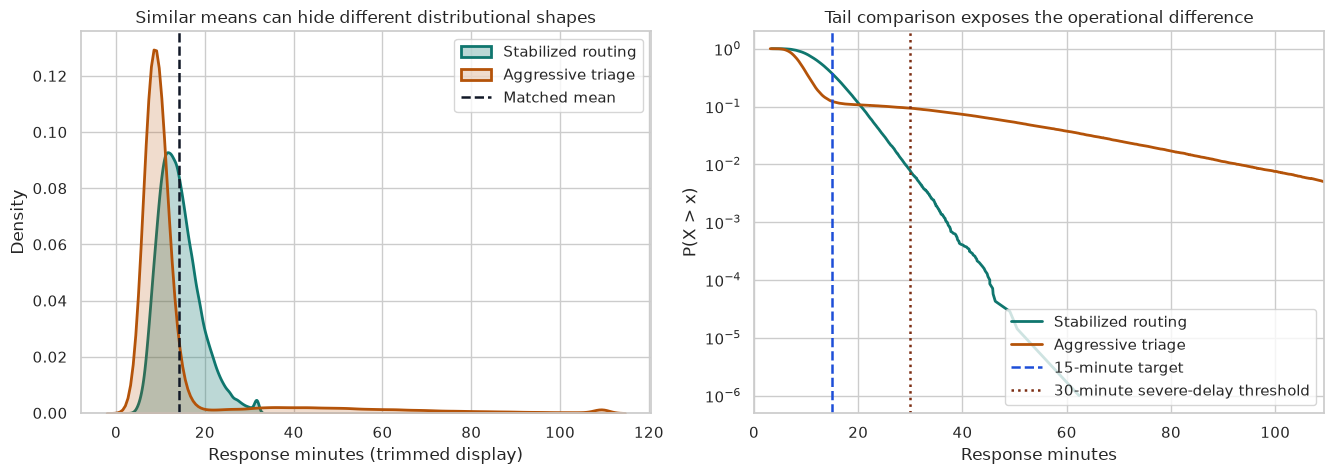

In [9]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
x_stable, y_stable = survival_xy(stable_policy)
x_unstable, y_unstable = survival_xy(unstable_policy)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.9))

stable_trim = np.clip(stable_policy, None, np.quantile(stable_policy, 0.995))
unstable_trim = np.clip(unstable_policy, None, np.quantile(unstable_policy, 0.995))

sns.kdeplot(stable_trim, fill=True, alpha=0.28, linewidth=2, label="Stabilized routing", color="#0f766e", ax=axes[0])
sns.kdeplot(unstable_trim, fill=True, alpha=0.20, linewidth=2, label="Aggressive triage", color="#b45309", ax=axes[0])
axes[0].axvline(np.mean(stable_policy), color="#111827", linestyle="--", linewidth=1.8, label="Matched mean")
axes[0].set_title("Similar means can hide different distributional shapes")
axes[0].set_xlabel("Response minutes (trimmed display)")
axes[0].legend()

axes[1].semilogy(x_stable, y_stable, color="#0f766e", linewidth=2, label="Stabilized routing")
axes[1].semilogy(x_unstable, y_unstable, color="#b45309", linewidth=2, label="Aggressive triage")
axes[1].axvline(15, color="#1d4ed8", linestyle="--", linewidth=1.8, label="15-minute target")
axes[1].axvline(30, color="#7c2d12", linestyle=":", linewidth=1.8, label="30-minute severe-delay threshold")
axes[1].set_xlim(0, np.quantile(unstable_policy, 0.995))
axes[1].set_title("Tail comparison exposes the operational difference")
axes[1].set_xlabel("Response minutes")
axes[1].set_ylabel("P(X > x)")
axes[1].legend()

plt.tight_layout()
plt.show()


This comparison is the heart of the notebook. The two policies are designed to have nearly the same mean, yet they are not operationally equivalent.

Aggressive triage looks attractive near the center because many tickets are handled very quickly, which lowers the median and can even reduce the share of modest SLA breaches. But the right tail is much heavier, which pushes up the 95th and 99th percentiles and sharply increases the probability of serious delays. Stabilized routing gives up some center-speed advantage in exchange for a calmer upper tail.

That trade-off is exactly the lesson. Distributional rankings depend on what part of the distribution matters to the decision. If the business cares about avoiding catastrophic experiences, the extreme tail must be treated as part of the service design.

## 7. Distribution-Aware Daily Risk Comparison

Ticket-level tails eventually become day-level operational pain. We now simulate many days under each policy to compare the probability of bad service days.


In [10]:
# Define helper functions so repeated calculations stay readable.
def simulate_policy_days(response_times, tickets_per_day=220, n_days=1200, seed=0):
    """
    Simulate policy days for intuition, calibration, or operating-characteristic checks.
    
    Parameters:
        response_times: Response-time values used to simulate daily policy outcomes.
        tickets_per_day: Number of tickets assigned to each simulated day.
        n_days: Sample size or group size used by the simulation, resampling, or inference step.
        seed: Random seed used to make the simulation or resampling reproducible.
    
    Returns:
        A pandas DataFrame of simulated daily policy outcomes used to compare service designs under operational uncertainty.
    
    Idea:
        Simulate repeated operational days so policy comparisons include volatility and tail risk, average performance and tail behavior.
    """
    local_rng = np.random.default_rng(seed)
    response_times = np.asarray(response_times)
    out = []
    for day in range(n_days):
        sample = response_times[local_rng.integers(0, len(response_times), size=tickets_per_day)]
        breaches = sample > 15
        severe = sample > 30
        out.append(
            {
                "day_id": day + 1,
                "mean_response": sample.mean(),
                "p95_response": np.quantile(sample, 0.95),
                "breach_rate": breaches.mean(),
                "severe_delay_rate": severe.mean(),
            }
        )
    return pd.DataFrame(out)


stable_days = simulate_policy_days(stable_policy, seed=610)
unstable_days = simulate_policy_days(unstable_policy, seed=611)

daily_policy_compare = pd.DataFrame(
    [
        {
            "policy": "Stabilized routing",
            "expected_daily_mean_response": stable_days["mean_response"].mean(),
            "prob_daily_p95_over_30": (stable_days["p95_response"] > 30).mean(),
            "expected_daily_breach_rate": stable_days["breach_rate"].mean(),
            "prob_daily_severe_rate_over_0.08": (stable_days["severe_delay_rate"] > 0.08).mean(),
        },
        {
            "policy": "Aggressive triage",
            "expected_daily_mean_response": unstable_days["mean_response"].mean(),
            "prob_daily_p95_over_30": (unstable_days["p95_response"] > 30).mean(),
            "expected_daily_breach_rate": unstable_days["breach_rate"].mean(),
            "prob_daily_severe_rate_over_0.08": (unstable_days["severe_delay_rate"] > 0.08).mean(),
        },
    ]
)

smart_display(daily_policy_compare)

,policy,expected_daily_mean_response,prob_daily_p95_over_30,expected_daily_breach_rate,prob_daily_severe_rate_over_0.08
0,Stabilized routing,14.197,0.000,0.371,0.000
1,Aggressive triage,14.184,0.992,0.122,0.736


The useful information is what the average hides. Variability, skew, and tail exposure can make two options with similar means very different from a staffing, service, or budget perspective.


In [11]:
# Translate the computed evidence into a decision-oriented summary.
decision_recommendation = (
    "The two policies optimize different parts of the distribution. Aggressive triage reduces ordinary 15-minute breaches, but stabilized routing dramatically lowers the probability of extreme-delay days. For a premium promise where very bad experiences are unacceptable, stabilized routing is the safer default."
    if daily_policy_compare.loc[daily_policy_compare["policy"] == "Stabilized routing", "prob_daily_p95_over_30"].iloc[0]
    < daily_policy_compare.loc[daily_policy_compare["policy"] == "Aggressive triage", "prob_daily_p95_over_30"].iloc[0]
    else "The aggressive triage design is acceptable under the current thresholds, though it should still be monitored carefully for tail instability."
)

smart_display(decision_recommendation)


'The two policies optimize different parts of the distribution. Aggressive triage reduces ordinary 15-minute breaches, but stabilized routing dramatically lowers the probability of extreme-delay days. For a premium promise where very bad experiences are unacceptable, stabilized routing is the safer default.'

The daily comparison is where distributional thinking becomes managerial judgment. The trade-off is now clear: aggressive triage can look better on ordinary breach rate, while stabilized routing can look much better on high-percentile and severe-tail reliability.

This is a general lesson. Distribution-aware decisions depend on which failures the organization can tolerate. If moderate SLA misses are annoying but recoverable, one ranking may emerge. If rare meltdown days are reputation-damaging or contract-breaking, the ranking can reverse. The full distribution is what lets us say that professionally.

## Wrap-Up

We expanded the course from expected values to full distributional reasoning:

1. A distribution contains information about center, spread, asymmetry, and tail behavior.
2. Operational data often look like mixtures with several interacting sources of variation.
3. Means and medians can disagree when the right tail is substantial.
4. Quantiles and exceedance probabilities are often better aligned with service promises than averages alone.
5. Two systems with similar means can still produce very different tail risk.
6. Distribution-aware decisions are usually more reliable than average-only decisions.

The next statistical topics will build on this by developing conditional probability, base rates, and how uncertainty updates when new information arrives.


## References

- Anscombe, F. J. (1973). *Graphs in statistical analysis*. *The American Statistician*, 27(1), 17-21. [https://doi.org/10.1080/00031305.1973.10478966](https://doi.org/10.1080/00031305.1973.10478966)
- McGill, R., Tukey, J. W., & Larsen, W. A. (1978). *Variations of box plots*. *The American Statistician*, 32(1), 12-16. [https://doi.org/10.1080/00031305.1978.10479236](https://doi.org/10.1080/00031305.1978.10479236)
- Spiegelhalter, D., Pearson, M., & Short, I. (2011). *Visualizing uncertainty about the future*. *Science*, 333(6048), 1393-1400. [https://doi.org/10.1126/science.1191181](https://doi.org/10.1126/science.1191181)
- Tukey, J. W. (1962). *The future of data analysis*. *The Annals of Mathematical Statistics*, 33(1), 1-67. [https://doi.org/10.1214/aoms/1177704711](https://doi.org/10.1214/aoms/1177704711)
